# Edge IIoT - Data Cleaning

Column-level documentation and treatment decisions: [docs/preliminary.md](../../docs/preliminary.md)

In [149]:
LOAD_LARGE_CSV = True # Set to True if you want to load the DNN file instead of the ML one.

if LOAD_LARGE_CSV:
    filename = "DNN-EdgeIIoT-dataset"
else:
    filename = "ML-EdgeIIoT-dataset"

## 0 - Obtaining data 

In [150]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['raw_path']}\n")

csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / f"{filename}.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (2219201, 63)


In [151]:
df.loc[0, (df != '0').any(axis=0)]

frame.time             2021 11:44:10.081753000 
ip.src_host                       192.168.0.128
ip.dst_host                       192.168.0.101
arp.dst.proto_ipv4                            0
arp.opcode                                  0.0
                                ...            
mbtcp.len                                   0.0
mbtcp.trans_id                              0.0
mbtcp.unit_id                               0.0
Attack_label                                  0
Attack_type                              Normal
Name: 0, Length: 63, dtype: object

In [152]:
print("Column count:", len(df.columns))
print("\n--- Columns ---\n", df.columns)

Column count: 63

--- Columns ---
 Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.co

In [153]:
packet_types = []
for col in df.columns:
    if '.' in col:
        proto = col.split('.')[0]
        if proto not in packet_types:
            packet_types.append(proto)

print(f"\nPacket types: {packet_types}\n")


Packet types: ['frame', 'ip', 'arp', 'icmp', 'http', 'tcp', 'udp', 'dns', 'mqtt', 'mbtcp']



## 1 - Initial Exploration

### 1.1 - Data order

In [154]:
df['frame.time']

0           2021 11:44:10.081753000 
1           2021 11:44:10.162218000 
2           2021 11:44:10.162271000 
3           2021 11:44:10.162641000 
4           2021 11:44:10.166132000 
                     ...            
2219196     2021 23:24:32.816050000 
2219197     2021 23:24:32.816595000 
2219198     2021 23:24:32.818043000 
2219199     2021 23:24:32.820831000 
2219200     2021 23:24:32.823654000 
Name: frame.time, Length: 2219201, dtype: str

In [155]:
df['frame.time'] = df['frame.time'].str.strip()
converted_times = pd.to_datetime(df['frame.time'], format="%Y %H:%M:%S.%f", exact=False, errors='coerce')

noisy_count = converted_times.isna().sum()
print(f"Number noisy frame.times: {noisy_count}")
print(f"Percentage: {(noisy_count / len(df)) * 100:.4f}%\n")

Number noisy frame.times: 122782
Percentage: 5.5327%



In [156]:
#df['frame.time'] = converted_times
#df = df.dropna(subset=['frame.time'])
df['frame.time'] = converted_times.fillna(0)
df['frame.time'] = pd.to_datetime(df['frame.time'], errors='coerce')

In [157]:
df['frame.time'].describe()

count                          2219201
mean     2018-03-08 02:33:06.588868864
min                1970-01-01 00:00:00
25%      2021-01-01 16:32:53.505108992
50%      2021-01-01 19:09:15.791735040
75%      2021-01-01 20:52:37.296376064
max         2021-01-01 23:59:59.358821
Name: frame.time, dtype: object

### 1.2 -  Protocol

In [158]:
df['proto'] = 'noinfo'

#### 1.2.1 - ARP and ICMP

In [159]:
df.loc[df['arp.opcode'] != 0, 'proto'] = 'ARP'
df['proto'].value_counts()

proto
noinfo    2213347
ARP          5854
Name: count, dtype: int64

In [160]:
df.loc[(df['icmp.checksum'] != 0) | (df['icmp.seq_le'] != 0) | (df['icmp.transmit_timestamp'] != 0), 'proto'] = 'ICMP'
df['proto'].value_counts()

proto
noinfo    2084803
ICMP       128544
ARP          5854
Name: count, dtype: int64

#### 1.2.2 -  TCP and UDP

In [161]:
df.loc[(~df['tcp.srcport'].isin(['0.0', '0'])) | (~df['tcp.srcport'].isin(['0.0', '0'])), 'proto'] = 'TCP'
df['proto'].value_counts()

proto
TCP       2072675
ICMP       128544
noinfo      12128
ARP          5854
Name: count, dtype: int64

In [162]:
df.loc[(df['udp.port'] != 0), 'proto'] = 'UDP'
df['proto'].value_counts()

proto
TCP       2072308
ICMP       128544
noinfo       9901
ARP          5854
UDP          2594
Name: count, dtype: int64

#### 1.2.3 -  HTTP, DNS, MQTT and MBTCP

In [163]:
df.loc[~df['http.request.method'].isin(['0.0', '0']) , 'proto'] = 'HTTP'
df['proto'].value_counts()

proto
TCP       2040221
ICMP       128544
HTTP        32087
noinfo       9901
ARP          5854
UDP          2594
Name: count, dtype: int64

In [164]:
df.loc[df['dns.qry.qu'] != 0, 'proto'] = 'DNS'
df['proto'].value_counts()

proto
TCP       2040221
ICMP       128544
HTTP        32087
noinfo       9901
ARP          5854
DNS          2072
UDP           522
Name: count, dtype: int64

In [165]:
df.loc[(df['mqtt.msgtype'] != 0), 'proto'] = 'MQTT'
df['proto'].value_counts()

proto
TCP       1708138
MQTT       332083
ICMP       128544
HTTP        32087
noinfo       9901
ARP          5854
DNS          2072
UDP           522
Name: count, dtype: int64

In [166]:
df.loc[(df['tcp.srcport'] == 502) | (df['tcp.dstport'] == 502), 'proto'] = 'MBTCP'
df['proto'].value_counts()

proto
TCP       1707204
MQTT       332083
ICMP       128544
HTTP        32087
noinfo       9901
ARP          5854
DNS          2072
MBTCP         934
UDP           522
Name: count, dtype: int64

#### 1.2.4 -  No info Exploration

In [167]:
df_noinfo = df[df['proto'] == 'noinfo']

for index, row in df_noinfo.iterrows():
    cols = []

    for col, val in row.items():
        if col in ['frame.time', 'proto', 'ip.src_host', 'ip.dst_host',  'Attack_type', 'Attack_label']:
            continue
        if val not in [0, '0', '0.0', 0.0]:
            cols.append(col)
        
        if len(cols) > 0:
            print(f"--- {index} ---")
            print(cols)

--- 1615672 ---
['tcp.len']
--- 1615672 ---
['tcp.len', 'tcp.options']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 1615672 ---
['tcp.len', 'tcp.options', 'tcp.payload']
-

In [168]:
pd.crosstab(df_noinfo['ip.src_host'], df_noinfo['Attack_type'])

Attack_type,Backdoor,DDoS_HTTP,DDoS_ICMP,DDoS_UDP,Fingerprinting,MITM,Normal,Password,Port_Scanning,Ransomware,SQL_injection,Uploading,Vulnerability_scanner,XSS
ip.src_host,,,,,,,,,,,,,,
0,366,4,0,0,50,506,4647,42,684,534,30,41,39,493
0.0.0.0,45,0,1,0,6,58,685,2,80,65,4,4,4,61
192.168.0.1,0,0,0,0,0,2,0,0,0,0,0,0,0,0
192.168.0.101,0,0,0,0,0,155,0,0,0,0,0,0,0,0
192.168.0.128,92,0,0,2,12,4,694,11,80,130,8,8,6,124
192.168.0.152,0,0,0,0,0,120,0,0,0,0,0,0,0,0
192.168.0.170,0,0,0,0,0,2,0,0,0,0,0,0,0,0


In [169]:
pd.crosstab(df_noinfo['ip.dst_host'], df_noinfo['Attack_type'])

Attack_type,Backdoor,DDoS_HTTP,DDoS_ICMP,DDoS_UDP,Fingerprinting,MITM,Normal,Password,Port_Scanning,Ransomware,SQL_injection,Uploading,Vulnerability_scanner,XSS
ip.dst_host,,,,,,,,,,,,,,
0,366,4,0,2,50,0,4647,42,684,534,30,41,39,493
0.0,0,0,0,0,0,847,0,0,0,0,0,0,0,0
224.0.0.1,45,0,1,0,6,0,685,2,80,65,4,4,4,61
224.0.0.251,46,0,0,0,6,0,685,5,80,65,4,4,3,62
224.0.0.252,46,0,0,0,6,0,9,6,0,65,4,4,3,62


In [170]:
df.drop(df_noinfo.index, inplace=True)

## 2 - Treating Columns

In [171]:
def print_unique_values(df, column_names):
    for col in column_names:
        unique_values = df[col].unique()
        print(f"\n--- {col} --- \n{unique_values}\n")

def find_packet_type_columns(df, packet_type):
    return [col for col in df.columns if col.startswith(f'{packet_type}.')]

### 2.01 - Frame

In [172]:
cols = find_packet_type_columns(df, 'frame')
print("\n>>> FRAME COLUMNS <<<\n", cols)


>>> FRAME COLUMNS <<<
 ['frame.time']


In [173]:
flow_columns = ['ip.src_host', 'ip.dst_host','proto']
df['frame.time.order'] = df.groupby(flow_columns).cumcount() + 1

df['frame.time.order'].describe()

count    2.209300e+06
mean     1.600301e+05
std      1.468944e+05
min      1.000000e+00
25%      4.150700e+04
50%      1.152210e+05
75%      2.420070e+05
max      5.823190e+05
Name: frame.time.order, dtype: float64

In [174]:
df['frame.time.delta'] = df.groupby(flow_columns)['frame.time'].diff()
df['frame.time.delta'] = df['frame.time.delta'].dt.total_seconds()
df['frame.time.delta'] = df['frame.time.delta'].fillna(0)

df['frame.time.delta'].describe()

count    2.209300e+06
mean     4.668696e-02
std      2.265911e+02
min     -8.639811e+04
25%      1.120000e-04
50%      3.176000e-03
75%      1.966200e-02
max      7.735432e+04
Name: frame.time.delta, dtype: float64

In [175]:
df.drop(columns=['frame.time'], inplace=True)

### 2.02 - IP (Internet Protocol)

In [176]:
cols = find_packet_type_columns(df, 'ip')
print("\n>>> IP COLUMNS <<<\n", cols)


>>> IP COLUMNS <<<
 ['ip.src_host', 'ip.dst_host']


In [177]:
print_unique_values(df, ["ip.src_host"])


--- ip.src_host --- 
<StringArray>
[  '192.168.0.128',   '192.168.0.101',               '0',     '192.168.0.1',
   '146.101.60.86',  '168.167.71.131',   '94.228.220.14',         '0.0.0.0',
 '143.107.229.210',    '85.254.217.5',
 ...
   '49.213.24.129',   '9.176.158.227', '211.121.212.183',  '132.238.72.160',
    '6.158.67.223',  '166.75.162.225',   '70.162.34.183',    '40.13.95.244',
   '18.132.75.125',   '82.173.42.163']
Length: 137166, dtype: str



In [178]:
df[df['Attack_label'] == 1][['ip.src_host', 'ip.dst_host']].value_counts()

ip.src_host     ip.dst_host  
192.168.0.170   192.168.0.128    164980
192.168.0.128   192.168.0.170    143311
                0                110033
0               0                  2785
                0.0                 367
                                  ...  
166.75.162.225  192.168.0.128         1
70.162.34.183   192.168.0.128         1
40.13.95.244    192.168.0.128         1
18.132.75.125   192.168.0.128         1
82.173.42.163   192.168.0.128         1
Name: count, Length: 178019, dtype: int64

In [179]:
import ipaddress

def categorize_ip(ip_str):
    try:
        if ip_str in ['0', '0.0', 0]:
            return 'Malformed'
            
        ip = ipaddress.ip_address(ip_str)
        if ip.is_private:
            return 'Private'
        elif ip.is_multicast or ip.is_reserved:
            return 'Reserved'
        else:
            return 'Public'
    except ValueError:
        return 'Invalid'
    
df['ip.src_category'] = df['ip.src_host'].apply(categorize_ip)
df['ip.dst_category'] = df['ip.dst_host'].apply(categorize_ip)

In [180]:
df[df['Attack_label'] == 1][['ip.src_category', 'ip.dst_category']].value_counts()

ip.src_category  ip.dst_category
Private          Private            322924
                 Malformed          110033
Public           Private            106967
Private          Public              37320
Public           Public              10313
Reserved         Private              8974
Malformed        Malformed            3152
Name: count, dtype: int64

In [181]:
df[df['Attack_label'] == 0][['ip.src_category', 'ip.dst_category']].value_counts()

ip.src_category  ip.dst_category
Private          Private            1334224
Malformed        Malformed           275016
Private          Public                 208
Public           Private                135
Private          Reserved                34
Name: count, dtype: int64

In [182]:
df = pd.get_dummies(df, columns=['ip.src_category', 'ip.dst_category'], dtype=int)

In [183]:
df.drop(columns=['ip.src_host', 'ip.dst_host'], inplace=True)
print("\nDropped 'ip.src_host' column:", not 'ip.src_host' in df.columns)
print("\nDropped 'ip.dst_host' column:", not 'ip.dst_host' in df.columns)


Dropped 'ip.src_host' column: True

Dropped 'ip.dst_host' column: True


### 2.03 - ARP (Address Resolution Protocol)

In [184]:
cols = find_packet_type_columns(df, 'arp')
print("\n>>> ARP COLUMNS <<<\n", cols)


>>> ARP COLUMNS <<<
 ['arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4']


In [185]:
df.drop(columns=['arp.dst.proto_ipv4', 'arp.src.proto_ipv4'], inplace=True)
print("\nDropped 'arp.dst.proto_ipv4' column:", not 'arp.dst.proto_ipv4' in df.columns)
print("\nDropped 'arp.src.proto_ipv4' column:", not 'arp.src.proto_ipv4' in df.columns)


Dropped 'arp.dst.proto_ipv4' column: True

Dropped 'arp.src.proto_ipv4' column: True


In [186]:
print_unique_values(df, ['arp.hw.size'])


--- arp.hw.size --- 
[0. 6.]



In [187]:
print(
    "\n--- Count hw.size if arp.code != 0 ---\n",
    df[df['arp.opcode'] != 0.]['arp.hw.size'].value_counts(),
    "\n\n\n--- Correlation opcode to hw.size ---\n",
    f"{df[['arp.opcode', 'arp.hw.size']].corr()['arp.hw.size']['arp.opcode']:0.4f}"
)


--- Count hw.size if arp.code != 0 ---
 arp.hw.size
6.0    5854
Name: count, dtype: int64 


--- Correlation opcode to hw.size ---
 0.9443


In [188]:
df.drop(columns=['arp.hw.size'], inplace=True)
print("\nDropped 'arp.hw.size' column:", not 'arp.hw.size' in df.columns)


Dropped 'arp.hw.size' column: True


In [189]:
print_unique_values(df, ['arp.opcode'])


--- arp.opcode --- 
[0. 1. 2.]



In [190]:
df['arp.opcode_request'] = (df['arp.opcode'] == 1).astype(int)
df['arp.opcode_reply'] = (df['arp.opcode'] == 2).astype(int)

print(df[['arp.opcode_request', 'arp.opcode_reply']].sum())

arp.opcode_request    4333
arp.opcode_reply      1521
dtype: int64


In [191]:
df.drop(columns=['arp.opcode'], inplace=True)
print("\nDropped 'arp.opcode' column:", not 'arp.opcode' in df.columns)


Dropped 'arp.opcode' column: True


### 2.04 - ICMP (Internet Control Message Protocol)

In [192]:
cols = find_packet_type_columns(df, 'icmp')
print("\n>>> ICMP COLUMNS <<<\n", cols)


>>> ICMP COLUMNS <<<
 ['icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused']


In [193]:
print_unique_values(df, ['icmp.checksum'])


--- icmp.checksum --- 
[    0. 48853. 50901. ... 35149. 48711. 60230.]



In [194]:
df.drop(columns=['icmp.checksum'], inplace=True)
print("\nDropped 'icmp.checksum' column:", not 'icmp.checksum' in df.columns)


Dropped 'icmp.checksum' column: True


In [195]:
print_unique_values(df, ['icmp.seq_le'])


--- icmp.seq_le --- 
[    0.   256. 48546. ... 45298. 45509. 45523.]



In [196]:
df.drop(columns=['icmp.transmit_timestamp'], inplace=True)
print("\nDropped 'icmp.transmit_timestamp' column:", not 'icmp.transmit_timestamp' in df.columns)


Dropped 'icmp.transmit_timestamp' column: True


In [197]:
print_unique_values(df, ['icmp.unused'])


--- icmp.unused --- 
[0.]



In [198]:
df.drop(columns=['icmp.unused'], inplace=True)
print("\nDropped 'icmp.unused' column:", not 'icmp.unused' in df.columns)


Dropped 'icmp.unused' column: True


### 2.05 - HTTP (HyperText Transfer Protocol)

In [199]:
cols = find_packet_type_columns(df, 'http')
print("\n>>> HTTP COLUMNS <<<\n", cols)


>>> HTTP COLUMNS <<<
 ['http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port']


In [200]:
print_unique_values(df, ['http.file_data'])


--- http.file_data --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [201]:
df['http.file_data'] = df['http.file_data'].replace(['0', '0.0'], '')

In [202]:
print_unique_values(df, ['http.content_length'])


--- http.content_length --- 
[0.0000e+00 2.9800e+02 3.0300e+02 1.4650e+03 3.7000e+01 1.4150e+03
 3.8000e+01 2.7700e+02 3.0100e+02 2.7300e+02 3.1500e+02 3.6000e+01
 3.0700e+02 1.4040e+03 1.8240e+03 2.8000e+02 1.0000e+00 1.2000e+01
 5.7000e+01 1.1500e+02 1.1550e+03 5.0000e+00 7.1400e+02 4.4000e+01
 2.2000e+01 3.9000e+01 8.6000e+01 6.0000e+00 1.6400e+02 4.7000e+01
 2.6000e+01 1.4060e+03 1.1530e+03 5.9000e+01 2.6200e+02 9.3000e+01
 1.5400e+02 8.3655e+04 2.3000e+01 8.7000e+01 2.9900e+02 2.2900e+02
 4.7200e+02]



In [203]:
df['http.content_length'].describe()

count    2.209300e+06
mean     4.829780e+00
std      9.663787e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.365500e+04
Name: http.content_length, dtype: float64

In [204]:
print_unique_values(df, ['http.request.uri.query'])


--- http.request.uri.query --- 
<StringArray>
[                                                                                                                  '0.0',
                                                                                                                     '0',
                                                                                               'id=2&Submit=Submitid=53',
                                                                       'id=2%27.%22%29%28%2C.%28.%28&Submit=Submitid=53',
                                                                    'id=2%27FHBrxG%3C%27%22%3EBjxRQk&Submit=Submitid=53',
                                                 'id=2%29%20AND%209522%3D9017%20AND%20%285824%3D5824&Submit=Submitid=53',
                                                                           'id=2%20AND%205107%3D2126&Submit=Submitid=53',
                                                                  'id=2%20AND%201053%3D6910--%20kVQ

In [205]:
df['http.request.uri.query'] = df['http.request.uri.query'].replace(['0', '0.0'], '')

In [206]:
print_unique_values(df, ['http.request.method'])


--- http.request.method --- 
<StringArray>
['0.0', '0', 'GET', 'POST', 'PROPFIND', 'TRACE', 'OPTIONS', 'PUT', 'SEARCH']
Length: 9, dtype: str



In [207]:
methods = {
    'GET': 'http.request.method_get',
    'HEAD': 'http.request.method_head',
    'POST': 'http.request.method_post',
    'PUT': 'http.request.method_put',
    'DELETE': 'http.request.method_delete',
    'CONNECT': 'http.request.method_connect',
    'OPTIONS': 'http.request.method_options',
    'TRACE': 'http.request.method_trace',
    'PATCH': 'http.request.method_patch',
    'PROPFIND': 'http.request.method_propfind',
    'SEARCH': 'http.request.method_search'
}

active_http_columns = []
for method, col_name in methods.items():
    if (df['http.request.method'] == method).any():
        df[col_name] = (df['http.request.method'] == method).astype(int)
        active_http_columns.append(col_name)

print(df[active_http_columns].sum())

http.request.method_get         30474
http.request.method_post         1212
http.request.method_put             2
http.request.method_options         6
http.request.method_trace         387
http.request.method_propfind        4
http.request.method_search          2
dtype: int64


In [208]:
df.drop(columns=['http.request.method'], inplace=True)
print("\nDropped 'http.request.method' column:", not 'http.request.method' in df.columns)


Dropped 'http.request.method' column: True


In [209]:
print_unique_values(df, ['http.referer'])


--- http.referer --- 
<StringArray>
[                                                                 '0.0',
                                                                    '0',
                                                'TESTING_PURPOSES_ONLY',
 '() { _; } >_[$($())] { echo 93e4r0-CVE-2014-6278: true; echo;echo; }',
                                                            '127.0.0.1']
Length: 5, dtype: str



In [210]:
df['http.referer'] = df['http.referer'].replace(['0', '0.0'], '')

In [211]:
print_unique_values(df, ['http.request.full_uri'])


--- http.request.full_uri --- 
<StringArray>
[                                                                                                                                    '0.0',
                                                                                                                                       '0',
                                                                                     'http://192.168.0.128/DVWA/hackable/uploads/hack.php',
                                                           'http://192.168.0.128/DVWA/vulnerabilities/sqli_blind/?id=2&Submit=Submitid=53',
                                   'http://192.168.0.128/DVWA/vulnerabilities/sqli_blind/?id=2%27.%22%29%28%2C.%28.%28&Submit=Submitid=53',
                                'http://192.168.0.128/DVWA/vulnerabilities/sqli_blind/?id=2%27FHBrxG%3C%27%22%3EBjxRQk&Submit=Submitid=53',
             'http://192.168.0.128/DVWA/vulnerabilities/sqli_blind/?id=2%29%20AND%209522%3D9017%20AND%20%285824%3D

In [212]:
from urllib.parse import urlparse

def extract_path(full_uri):
    try:
        return urlparse(full_uri).path
    except Exception:
        return ''

# Apply to your dataframe
df['http.request.path'] = df['http.request.full_uri'].apply(extract_path)

In [213]:
print_unique_values(df, ['http.request.path'])


--- http.request.path --- 
<StringArray>
[                                          '0.0',
                                             '0',
               '/DVWA/hackable/uploads/hack.php',
             '/DVWA/vulnerabilities/sqli_blind/',
                                             '/',
                               '/DVWA/login.php',
                                        '/DVWA/',
                   '/DVWA/fd5ljfpL.LCDispatcher',
                       '/DVWA/fd5ljfpL.password',
                          '/DVWA/fd5ljfpL.shtml',
 ...
               '/DVWA/phpi/edit_top_feature.php',
 '/DVWA/phplib/version/1.3.3/standard/1/lay.php',
              '/DVWA/snort/base_stat_common.php',
          '/DVWA/source/mod/rss/channeledit.php',
      '/DVWA/speedberg/include/scriplet.inc.php',
                        '/DVWA/submit_abuse.php',
           '/DVWA/support/include/open_form.php',
            '/DVWA/sw/lib_up_file/find_file.php',
    '/DVWA/template/purpletech/base_include.php',
   

In [214]:
df['http.request.path'] = df['http.request.path'].replace(['0', '0.0'], '')

In [215]:
df.drop(columns=['http.request.full_uri'], inplace=True)
print("\nDropped 'http.request.full_uri' column:", not 'http.request.full_uri' in df.columns)


Dropped 'http.request.full_uri' column: True


In [216]:
print_unique_values(df, ['http.request.version'])


--- http.request.version --- 
<StringArray>
[                                                                            '0.0',
                                                                               '0',
                                                                        'HTTP/1.1',
                                                                        'HTTP/1.0',
 'name=a><input name=i value=XSS>&lt;script>alert('Vulnerable')</script> HTTP/1.1',
                         'Src=javascript:alert('Vulnerable')><Img Src=\" HTTP/1.1',
                                                                      '> HTTP/1.1',
                                             'script>alert(1)/script><\" HTTP/1.1',
                       '-al&_PHPLIB[libdir]=http://cirt.net/rfiinc.txt?? HTTP/1.1',
                                                                     '-a HTTP/1.1',
                                             '/etc/passwd|?data=Download HTTP/1.1',
                  '-al&ABSOLUTE

In [217]:
df['http.request.version'] = df['http.request.version'].replace(['0', '0.0'], '')

In [218]:
print_unique_values(df, ['http.response'])


--- http.response --- 
[0. 1.]



In [219]:
print_unique_values(df, ['http.tls_port'])


--- http.tls_port --- 
[0.]



### 2.06 - TCP (Transmission Control Protocol)

In [220]:
cols = find_packet_type_columns(df, 'tcp')
print("\n>>> TCP COLUMNS <<<\n", cols)


>>> TCP COLUMNS <<<
 ['tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport']


In [221]:
print_unique_values(df, ['tcp.ack'])


--- tcp.ack --- 
[1.000e+00 1.500e+01 5.000e+00 ... 1.908e+03 4.065e+03 4.844e+03]



In [222]:
df.drop(columns=['tcp.ack_raw'], inplace=True)
print("\nDropped 'tcp.ack_raw' column:", not 'tcp.ack_raw' in df.columns)


Dropped 'tcp.ack_raw' column: True


In [223]:
df.groupby('tcp.checksum')['Attack_label'].value_counts().unstack(fill_value=0)

Attack_label,0,1
tcp.checksum,,
0.0,5307,241731
1.0,20,5
2.0,31,6
3.0,15,10
4.0,27,8
...,...,...
65531.0,13,4
65532.0,26,8
65533.0,21,8


In [224]:
df['tcp.nullchecksum'] = (df['tcp.checksum'] == '0').astype(int)

In [225]:
df.drop(columns=['tcp.checksum'], inplace=True)
print("\nDropped 'tcp.checksum' column:", not 'tcp.checksum' in df.columns)


Dropped 'tcp.checksum' column: True


In [226]:
for col in ['tcp.dstport', 'tcp.srcport']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'tcp.dstport' column: True

Dropped 'tcp.srcport' column: True


In [227]:
df['tcp.flags'].value_counts()

tcp.flags
16.0    871609
24.0    436137
0.0     247025
4.0     166579
2.0     156680
17.0    109645
18.0    100397
25.0     83135
20.0     38093
Name: count, dtype: int64

In [228]:
tcp_flags_map = {
        'tcp.flag.res': 0x200, # Reserved
        'tcp.flag.ns':  0x100, # NS
        'tcp.flag.cwr': 0x080, # CWR
        'tcp.flag.ece': 0x040, # ECE
        'tcp.flag.urg': 0x020, # Urg
        'tcp.flag.ack': 0x010, # Ack
        'tcp.flag.psh': 0x008, # Push
        'tcp.flag.rst': 0x004, # Reset
        'tcp.flag.syn': 0x002, # Syn
        'tcp.flag.fin': 0x001  # Fin
    }

df['tcp.flags'] = df['tcp.flags'].astype(int)

for flag_name, bit_mask in tcp_flags_map.items():
    df[flag_name] = (df['tcp.flags'] & bit_mask).gt(0).astype('uint8')

In [229]:
df.drop(columns=['tcp.flags'], inplace=True)
print("\nDropped 'tcp.flags' column:", not 'tcp.flags' in df.columns)


Dropped 'tcp.flags' column: True


In [230]:
for col in ['tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags.ack']:
    print(f"{col:>25}: {df[df['tcp.ack'] > 0][col].unique()}")

       tcp.connection.fin: [0. 1.]
       tcp.connection.rst: [0. 1.]
       tcp.connection.syn: [0. 1.]
    tcp.connection.synack: [1. 0.]
            tcp.flags.ack: [1. 0.]


In [231]:
print("--- Correlation between TCP flags ---")
print(f"{"FIN":>10}: {df[['tcp.connection.fin', 'tcp.flag.fin']].corr()['tcp.flag.fin']['tcp.connection.fin']:0.4f}")
print(f"{"RST":>10}: {df[['tcp.connection.rst', 'tcp.flag.rst']].corr()['tcp.flag.rst']['tcp.connection.rst']:0.4f}")
print(f"{"SYN":>10}: {df[['tcp.connection.syn', 'tcp.flag.syn']].corr()['tcp.flag.syn']['tcp.connection.syn']:0.4f}")
print(f"{"ACK":>10}: {df[['tcp.flags.ack',      'tcp.flag.ack']].corr()['tcp.flag.ack']['tcp.flags.ack'     ]:0.4f}")

--- Correlation between TCP flags ---
       FIN: 1.0000
       RST: 1.0000
       SYN: 0.7614
       ACK: 1.0000


In [232]:
for col in ['tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags.ack']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'tcp.connection.fin' column: True

Dropped 'tcp.connection.rst' column: True

Dropped 'tcp.connection.syn' column: True

Dropped 'tcp.connection.synack' column: True

Dropped 'tcp.flags.ack' column: True


In [233]:
df[df['tcp.len'] > 0]['tcp.len'].describe()

count    656043.000000
mean        410.658757
std         847.744979
min           1.000000
25%           4.000000
50%          41.000000
75%         495.000000
max       65228.000000
Name: tcp.len, dtype: float64

In [234]:
print_unique_values(df, ['tcp.options'])


--- tcp.options --- 
<StringArray>
['020405b40101040201030307',                        '0',
 '020405b40103030801010402', '0101050ae166d543e166d56f',
 '0101050a8784aa8a8784aa98', '0101050a03f9c39703f9c39b',
 '0101050a85a2caaa85a2caab', '0101050a7026f0cd7026f0ce',
 '0101050a6cc4639a6cc4639b', '0101050a5787a94c5787a94d',
 ...
 '0101080a9ac0f5f59e4e88b7', '0101080a9e4e88bb9ac0f5f5',
 '0101080a9e4e88bc9ac0f5f5', '0101080a9ac0f5fb9e4e88bc',
 '0101080a9e4e88c19ac0f5fb', '0101080a9ac0f5f49e4e88b7',
 '0101080a9e4e88c59ac0f5fb', '0101080a9ac0f5fa9e4e88bc',
 '0101080a9ac0f5fe9e4e88c1', '0101080a9ac0f6019e4e88c1']
Length: 242560, dtype: str



In [235]:
df.drop(columns=['tcp.options'], inplace=True)
print("\nDropped 'tcp.options' column:", not 'tcp.options' in df.columns)


Dropped 'tcp.options' column: True


In [236]:
df.drop(columns=['tcp.payload'], inplace=True)
print("\nDropped 'tcp.payload' column:", not 'tcp.payload' in df.columns)


Dropped 'tcp.payload' column: True


In [237]:
print_unique_values(df, ['tcp.seq'])


--- tcp.seq --- 
[0.000e+00 1.000e+00 1.500e+01 ... 1.295e+03 4.065e+03 4.844e+03]



In [238]:
df[df['tcp.seq'] > 0]['tcp.seq'].describe()

count    1.705489e+06
mean     1.129823e+07
std      3.928726e+07
min      4.000000e-05
25%      1.000000e+00
50%      6.000000e+00
75%      5.900000e+01
max      4.294967e+09
Name: tcp.seq, dtype: float64

### 2.07 - UDP (User Datagram Protocol)

In [239]:
cols = find_packet_type_columns(df, 'udp')
print("\n>>> UDP COLUMNS <<<\n", cols)


>>> UDP COLUMNS <<<
 ['udp.port', 'udp.stream', 'udp.time_delta']


In [240]:
df.drop(columns=['udp.port'], inplace=True)
print("\nDropped 'udp.port' column:", not 'udp.port' in df.columns)


Dropped 'udp.port' column: True


In [241]:
print_unique_values(df, ['udp.stream'])


--- udp.stream --- 
[0.000000e+00 1.230000e+02 6.054200e+04 ... 2.898761e+06 2.898764e+06
 2.898776e+06]



In [242]:
df[df['udp.stream'] > 0]['udp.stream'].describe()

count    1.237930e+05
mean     1.290500e+06
std      9.066458e+05
min      1.000000e+00
25%      4.506210e+05
50%      1.262405e+06
75%      2.086440e+06
max      2.898776e+06
Name: udp.stream, dtype: float64

In [243]:
df[df['udp.stream'] > 0]['udp.stream'].describe()

count    1.237930e+05
mean     1.290500e+06
std      9.066458e+05
min      1.000000e+00
25%      4.506210e+05
50%      1.262405e+06
75%      2.086440e+06
max      2.898776e+06
Name: udp.stream, dtype: float64

### 2.08 - DNS (Domain Name System)

In [244]:
cols = find_packet_type_columns(df, 'dns')
print("\n>>> DNS COLUMNS <<<\n", cols)


>>> DNS COLUMNS <<<
 ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in']


In [245]:
print_unique_values(df, ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type'])


--- dns.qry.name --- 
[0.0000000e+00 3.2250063e+01 2.5326700e-01 ... 2.8985160e+06 2.8985210e+06
 2.8985220e+06]


--- dns.qry.name.len --- 
<StringArray>
[                     '0',  '0.debian.pool.ntp.org',  '1.debian.pool.ntp.org',
  '2.debian.pool.ntp.org',  '3.debian.pool.ntp.org', '_googlecast._tcp.local',
      'raspberrypi.local',        'null-null.local',                    '0.0',
                    '1.0']
Length: 10, dtype: str


--- dns.qry.qu --- 
[   0.   21.   22.   17.   15.   37.   38.   70.   71.   95.   96.  120.
  121.  166.  167.  197.  198.  243.  244.  268.  271.  325.  326.  342.
  346.  371.  372.  398.  399.  420.  421.  441.  443.  476.  477.  517.
  518.  574.  575.  599.  600.  629.  630.  655.  656.  687.  688.  731.
  732.  748.  751.  780.  781.  801.  802.  828.  829.  848.  851.  908.
  909.  925.  928.  954.  957. 1001. 1027. 1028.]


--- dns.qry.type --- 
[0.]



In [246]:
print(df[['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']].dtypes)

dns.qry.name        float64
dns.qry.name.len        str
dns.qry.qu          float64
dns.qry.type        float64
dtype: object


In [247]:
df[~df['dns.qry.name.len'].isin(['0.0', '1.0', '0'])][['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'Attack_label']].head()

,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,Attack_label
1270940,0.000000,0.debian.pool.ntp.org,21.0,0.0,0
1270941,0.000075,0.debian.pool.ntp.org,21.0,0.0,0
1271008,5.005134,0.debian.pool.ntp.org,21.0,0.0,0
1271009,0.000038,0.debian.pool.ntp.org,21.0,0.0,0
1271095,0.000000,1.debian.pool.ntp.org,21.0,0.0,0


In [248]:
for col in ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'dns.qry.name' column: True

Dropped 'dns.qry.name.len' column: True

Dropped 'dns.qry.qu' column: True

Dropped 'dns.qry.type' column: True


In [249]:
print_unique_values(df, ['dns.retransmission'])


--- dns.retransmission --- 
[ 0.  1. 28. 12.]



In [250]:
df['dns.retransmission'].value_counts()

dns.retransmission
0.0     2207455
1.0         940
28.0        899
12.0          6
Name: count, dtype: int64

In [251]:
df[df['dns.retransmission'] > 0]['Attack_label'].value_counts()

Attack_label
0    1845
Name: count, dtype: int64

In [252]:
print_unique_values(df, ['dns.retransmit_request'])


--- dns.retransmit_request --- 
[0. 1.]



In [253]:
df['dns.retransmit_request'].value_counts()

dns.retransmit_request
0.0    2209251
1.0         49
Name: count, dtype: int64

In [254]:
df[df['dns.retransmit_request'] == 1]['Attack_label'].value_counts()

Attack_label
0    49
Name: count, dtype: int64

In [255]:
print_unique_values(df, ['dns.retransmit_request_in'])


--- dns.retransmit_request_in --- 
[0. 1.]



In [256]:
df[df['dns.retransmit_request_in'] == 1]['Attack_label'].value_counts()

Attack_label
0    40
Name: count, dtype: int64

### 2.09 - MQTT (Message Queuing Telemetry Transport)

In [257]:
cols = find_packet_type_columns(df, 'mqtt')
print("\n>>> MQTT COLUMNS <<<\n", cols)


>>> MQTT COLUMNS <<<
 ['mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msg', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic', 'mqtt.topic_len', 'mqtt.ver']


In [258]:
print_unique_values(df, ['mqtt.conack.flags'])


--- mqtt.conack.flags --- 
<StringArray>
[         '0', '0x00000000',    '1461073',    '1461074',    '1461383',
    '1461384',    '1461589',    '1461591',    '1471198',    '1471199',
    '1574358',    '1574359',        '0.0']
Length: 13, dtype: str



In [259]:
df['mqtt.conack.flags'] = df['mqtt.conack.flags'].replace(['0', '0.0', '0x00000000'], '0')
df['mqtt.conack.flags'] = pd.to_numeric(df['mqtt.conack.flags']).astype(int)

df['mqtt.conack.flags'].describe()

count    2.209300e+06
mean     2.739698e+01
std      6.442983e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.574359e+06
Name: mqtt.conack.flags, dtype: float64

In [260]:
pd.crosstab(df['mqtt.conack.flags'], df['Attack_label'])

Attack_label,0,1
mqtt.conack.flags,,
0,1609577,599683
1461073,2,0
1461074,2,0
1461383,4,0
1461384,4,0
1461589,3,0
1461591,3,0
1471198,2,0
1471199,2,0


In [261]:
print_unique_values(df, ['mqtt.conflag.cleansess'])


--- mqtt.conflag.cleansess --- 
[0. 1.]



In [262]:
pd.crosstab(df['mqtt.conflag.cleansess'], df['Attack_label'])

Attack_label,0,1
mqtt.conflag.cleansess,,
0.0,1526582,599683
1.0,83035,0


In [263]:
print_unique_values(df, ['mqtt.conflags'])


--- mqtt.conflags --- 
[0. 2.]



In [264]:
print("Correlation:", df[['mqtt.conflag.cleansess', 'mqtt.conflags']].corr()['mqtt.conflag.cleansess']['mqtt.conflags'])

Correlation: 1.0


In [265]:
df.drop(columns=['mqtt.conflags'], inplace=True)
print("\nDropped 'mqtt.conflags' column:", not 'mqtt.conflags' in df.columns) 


Dropped 'mqtt.conflags' column: True


In [266]:
print_unique_values(df, ['mqtt.len'])


--- mqtt.len --- 
[ 0. 12.  2. 39.]



In [267]:
df['mqtt.len'].describe()

count    2.209300e+06
mean     1.991616e+00
std      7.664762e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.900000e+01
Name: mqtt.len, dtype: float64

In [268]:
print_unique_values(df, ['mqtt.msg_decoded_as'])


--- mqtt.msg_decoded_as --- 
[0.]



In [269]:
df.drop(columns=['mqtt.msg_decoded_as'], inplace=True)
print("\nDropped 'mqtt.msg_decoded_as' columns:", not 'mqtt.msg_decoded_as' in df.columns)


Dropped 'mqtt.msg_decoded_as' columns: True


In [270]:
print_unique_values(df, ['mqtt.msg'])


--- mqtt.msg --- 
<StringArray>
[                         '0', '32342e36382037362e34320d0a',
 '32342e37392037362e36320d0a', '32342e37302037362e34370d0a',
 '32342e38312037362e36360d0a', '32342e35372037362e32320d0a',
 '32342e35392037362e32370d0a', '32342e34382037362e30370d0a',
 '32342e33372037352e38370d0a', '32342e32362037352e36370d0a',
 ...
 '32342e31322037352e34320d0a', '32342e31372037352e35310d0a',
 '32342e32302037352e35360d0a', '32342e33342037352e38300d0a',
 '32342e35322037362e31340d0a', '32332e34342037342e31390d0a',
 '32332e38372037342e39380d0a', '32332e39302037352e30320d0a',
 '32332e39332037352e30370d0a',                        '0.0']
Length: 136, dtype: str



In [271]:
df['mqtt.msg'] = df['mqtt.msg'].replace(['0', '0.0'], '')

In [272]:
print_unique_values(df, ['mqtt.msgtype'])


--- mqtt.msgtype --- 
[ 0.  1.  2.  3. 14.]



In [273]:
# MQTT v3.1.1 msg type codes
mqtt_types = {
    1: 'mqtt.msgtype_connect',
    2: 'mqtt.msgtype_connack',
    3: 'mqtt.msgtype_publish',
    4: 'mqtt.msgtype_puback',
    5: 'mqtt.msgtype_pubrec',
    6: 'mqtt.msgtype_pubrel',
    7: 'mqtt.msgtype_pubcomp',
    8: 'mqtt.msgtype_subscribe',
    9: 'mqtt.msgtype_suback',
    10: 'mqtt.msgtype_unsubscribe',
    11: 'mqtt.msgtype_unsuback',
    12: 'mqtt.msgtype_pingreq',
    13: 'mqtt.msgtype_pingresp',
    14: 'mqtt.msgtype_disconnect'
}

active_mqtt_columns = []
for code, col_name in mqtt_types.items():
    if (df['mqtt.msgtype'] == code).any():
        df[col_name] = (df['mqtt.msgtype'] == code).astype(int)
        active_mqtt_columns.append(col_name)

print(df[active_mqtt_columns].sum())

mqtt.msgtype_connect       83035
mqtt.msgtype_connack       83017
mqtt.msgtype_publish       83016
mqtt.msgtype_disconnect    83015
dtype: int64


In [274]:
print_unique_values(df, ['mqtt.hdrflags'])


--- mqtt.hdrflags --- 
[  0.  16.  32.  48. 224.]



In [275]:
print([format(int(i), '08b') for i in df['mqtt.hdrflags'].unique()])

['00000000', '00010000', '00100000', '00110000', '11100000']


In [276]:
print("mqtt.msgtype: ", [int(i) for i in df['mqtt.msgtype'].unique().astype(int)])
print("mqtt.hdrflags:", [int(i) >> 4 for i in df['mqtt.hdrflags'].unique()], "\t(4-bit shift to the right)")

mqtt.msgtype:  [0, 1, 2, 3, 14]
mqtt.hdrflags: [0, 1, 2, 3, 14] 	(4-bit shift to the right)


In [277]:
df.drop(columns=['mqtt.hdrflags'], inplace=True)
print("\nDropped 'mqtt.hdrflags' columns:", not 'mqtt.hdrflags' in df.columns)


Dropped 'mqtt.hdrflags' columns: True


In [278]:
print_unique_values(df, ['mqtt.proto_len', 'mqtt.protoname'])


--- mqtt.proto_len --- 
[0. 4.]


--- mqtt.protoname --- 
<StringArray>
['0', 'MQTT', '0.0']
Length: 3, dtype: str



In [279]:
df[['mqtt.proto_len', 'mqtt.protoname']].value_counts()

mqtt.proto_len  mqtt.protoname
0.0             0                 1526582
                0.0                599683
4.0             MQTT                83035
Name: count, dtype: int64

In [280]:
for col in ['mqtt.proto_len', 'mqtt.protoname']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'mqtt.proto_len' column: True

Dropped 'mqtt.protoname' column: True


In [281]:
print_unique_values(df, ['mqtt.topic', 'mqtt.topic_len'])


--- mqtt.topic --- 
<StringArray>
['0', 'Temperature_and_Humidity', '0.0']
Length: 3, dtype: str


--- mqtt.topic_len --- 
[ 0. 24.]



In [282]:
for col in ['mqtt.topic', 'mqtt.topic_len']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'mqtt.topic' column: True

Dropped 'mqtt.topic_len' column: True


In [283]:
print_unique_values(df, ['mqtt.ver'])


--- mqtt.ver --- 
[0. 4.]



In [284]:
df.drop(columns=['mqtt.ver'], inplace=True)
print("\nDropped 'mqtt.ver' column:", not 'mqtt.ver' in df.columns)


Dropped 'mqtt.ver' column: True


### 2.10 - MBTCP (ModBus TCP)

In [285]:
cols = find_packet_type_columns(df, 'mbtcp')
print("\n>>> MBTCP COLUMNS <<<\n", cols)


>>> MBTCP COLUMNS <<<
 ['mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id']


In [286]:
print_unique_values(df, ['mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id'])


--- mbtcp.len --- 
[ 0.  9.  6. 17. 19. 21.  5. 27.]


--- mbtcp.trans_id --- 
[  0.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151.]


--- mbtcp.unit_id --- 
[0. 1. 2. 3. 4. 6.]



In [287]:
df[df['mbtcp.len'] > 0]['Attack_label'].value_counts()

Attack_label
0    150
Name: count, dtype: int64

In [288]:
df[df['mbtcp.trans_id'] > 0]['Attack_label'].value_counts()

Attack_label
0    150
Name: count, dtype: int64

In [289]:
df[df['mbtcp.unit_id'] > 0]['Attack_label'].value_counts()

Attack_label
0    150
Name: count, dtype: int64

## 3 - Columns after treatment

In [290]:
print("Column count:", len(df.columns), "\t(Innitial count was 63)")
print("\n--- Columns ---\n", df.columns)

Column count: 62 	(Innitial count was 63)

--- Columns ---
 Index(['icmp.seq_le', 'http.file_data', 'http.content_length',
       'http.request.uri.query', 'http.referer', 'http.request.version',
       'http.response', 'http.tls_port', 'tcp.ack', 'tcp.len', 'tcp.seq',
       'udp.stream', 'udp.time_delta', 'dns.retransmission',
       'dns.retransmit_request', 'dns.retransmit_request_in',
       'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.len', 'mqtt.msg',
       'mqtt.msgtype', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id',
       'Attack_label', 'Attack_type', 'proto', 'frame.time.order',
       'frame.time.delta', 'ip.src_category_Malformed',
       'ip.src_category_Private', 'ip.src_category_Public',
       'ip.src_category_Reserved', 'ip.dst_category_Malformed',
       'ip.dst_category_Private', 'ip.dst_category_Public',
       'ip.dst_category_Reserved', 'arp.opcode_request', 'arp.opcode_reply',
       'http.request.method_get', 'http.request.method_post',
       'http

In [291]:
dup_count = df.duplicated().sum()
total_count = len(df)
print(f"Num. duplicates: {dup_count}\t(TOTAL = {total_count}, PERCENTAJE = {dup_count / total_count * 100:.2f}%)")

Num. duplicates: 60265	(TOTAL = 2209300, PERCENTAJE = 2.73%)


In [292]:
df_duplicados = df[df.duplicated(keep='first')]
df_duplicados['Attack_type'].value_counts()

Attack_type
DDoS_ICMP                39351
DDoS_TCP                 20907
Vulnerability_scanner        3
XSS                          2
Normal                       1
Fingerprinting               1
Name: count, dtype: int64

In [293]:
df = df.drop_duplicates(keep='first')
print(f"Num. duplicates after treatment: {df.duplicated().sum()}")

Num. duplicates after treatment: 0


In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df_data, label_col):

    conteo = df_data[label_col].value_counts()
    labels = conteo.index
    sizes = conteo.values

    palette_colors = sns.color_palette("viridis", len(labels))
    color_map = dict(zip(labels, palette_colors))

    explode = [0.05] * len(labels)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # --- Barplot ---
    sns.countplot(y=label_col,
                  data=df_data,
                  ax=ax1,
                  order=labels,
                  hue=label_col,
                  palette=color_map,
                  legend=False)

    ax1.set_title(f"Count of each {label_col}")
    ax1.set_xlabel("Count")
    ax1.set_ylabel(label_col)

    # --- Donut ---
    pie_colors = [color_map[label] for label in labels]

    ax2.pie(sizes,
            explode=explode,
            labels=labels,
            autopct='%1.1f%%',
            startangle=60,
            pctdistance=0.85,
            colors=pie_colors)

    center_circle = plt.Circle((0,0), 0.70, fc='white')
    ax2.add_artist(center_circle)

    ax2.set_title(f"Percentage of each {label_col}")

    plt.tight_layout()
    plt.show()

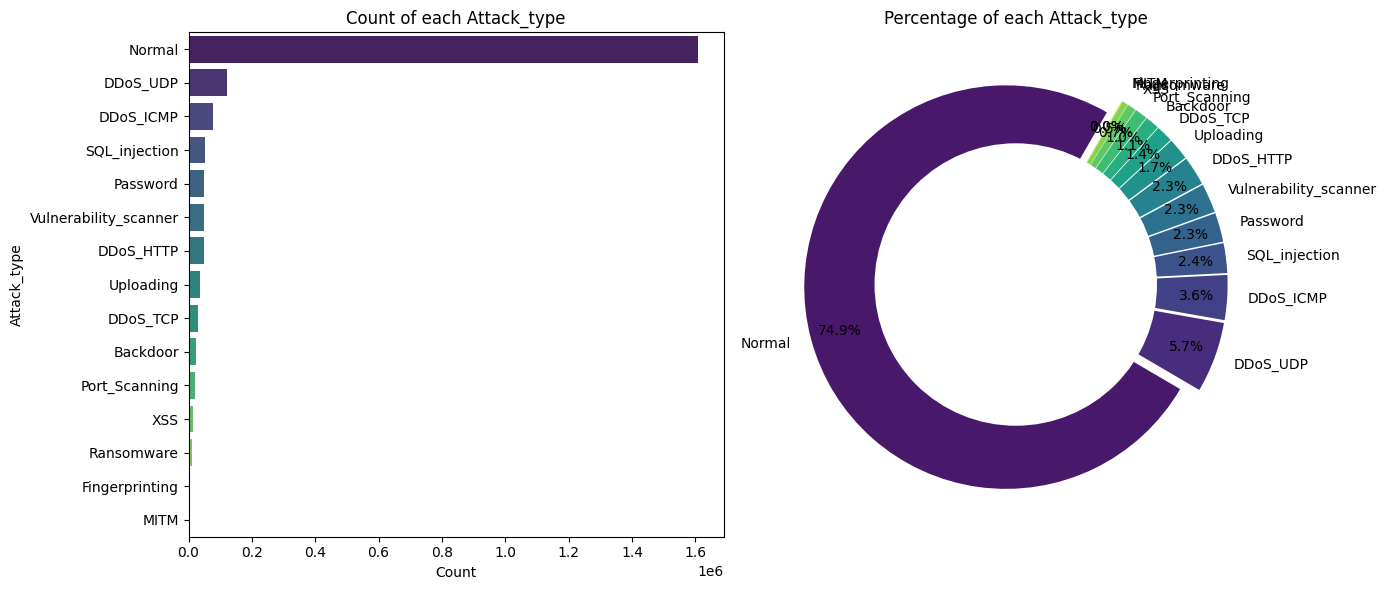

In [295]:
label_col = "Attack_type"
plot_label_distribution(df, label_col)

## 4 - Saving Data

In [296]:
pd.to_pickle(df, config['processed_path'] / f"{filename}.pkl")